In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import kagglehub
import os
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

Завантаження та підготовка даних

a. Завантажити набір даних.

b. Вивести перші кілька рядків і статистики колонок.

c. Виконати стандартизацію числових ознак.

d. Для зменшення кількості точок у візуалізації залишити лише треки з popularity ≥ 85. (Решту треків можна використати для навчання моделі, але візуалізувати лише популярні.)

e. Вивести розмірність таблиці після фільтрації.


In [44]:
folder_path = kagglehub.dataset_download("zaheenhamidani/ultimate-spotify-tracks-db")

file_path = os.path.join(folder_path, 'SpotifyFeatures.csv')

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print("Помилка")

display(df.head())
display(df.describe())

numeric_cols = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 
    'valence', 'tempo', 'duration_ms'
]

# popularity >= 85
df_filtered = df[df['popularity'] >= 85].copy()
print(f"Розмірність таблиці ДО фільтрації: {df.shape}")
print(f"Розмірність таблиці ПІСЛЯ фільтрації: {df_filtered.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filtered[numeric_cols])

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


Розмірність таблиці ДО фільтрації: (232725, 18)
Розмірність таблиці ПІСЛЯ фільтрації: (417, 18)


2. Підбір оптимальної кількості кластерів (k) — метод ліктя

a. Ініціалізувати модель KMeans із різною кількістю кластерів (наприклад k = 2…15).
    
b. Для кожного k обчислити інерцію (суму квадратів відстаней до центрів кластерів).

c. Побудувати графік залежності інерції від k.
    
d. Визначити оптимальне k.


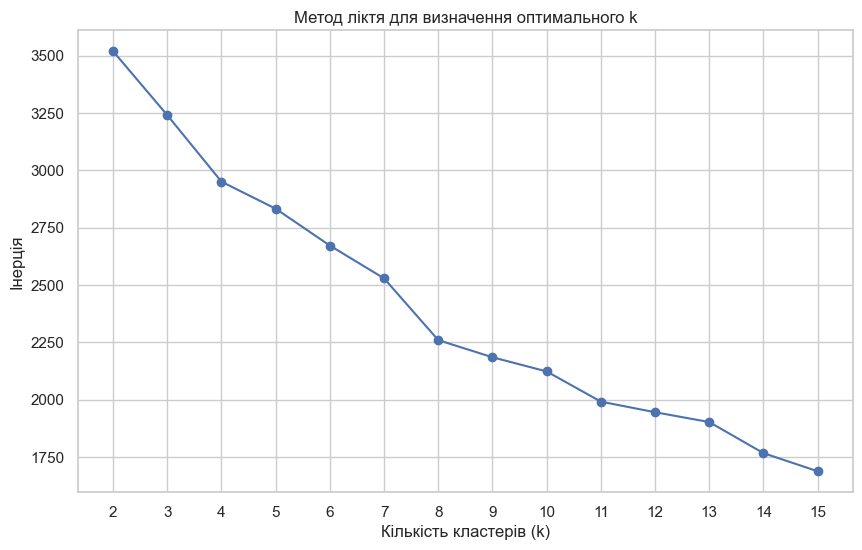

In [45]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
import os

os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

inertia = []
K_range = range(2, 16) # Від 2 до 15 кластерів

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.title('Метод ліктя для визначення оптимального k')
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Інерція')
plt.xticks(K_range)
plt.grid(True)
plt.show()

3. Побудова кластеризації
 
а. Виконати кластеризацію з обраним значенням k.

b. Додати отримані мітки кластерів до DataFrame як нову колонку cluster.

c. Вивести кількість треків у кожному кластері.

In [46]:
optimal_k = 8

print(f"Кластеризацію для k = {optimal_k}...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')

df_filtered['cluster'] = kmeans.fit_predict(X_scaled)

print("\nКількість треків у кожному кластері:")
print(df_filtered['cluster'].value_counts().sort_index())

Кластеризацію для k = 8...

Кількість треків у кожному кластері:
cluster
0     42
1     39
2     77
3    105
4     92
5      1
6     19
7     42
Name: count, dtype: int64


4. Візуалізація кластерів у просторі головних компонент
 
a. Виконати PCA до двох/трьох компонент для візуалізації.

b. Побудувати 2D/3D-графік з кольором точок за значенням cluster. Для покращення читабельності візуалізувати лише треки з popularity ≥ 85.

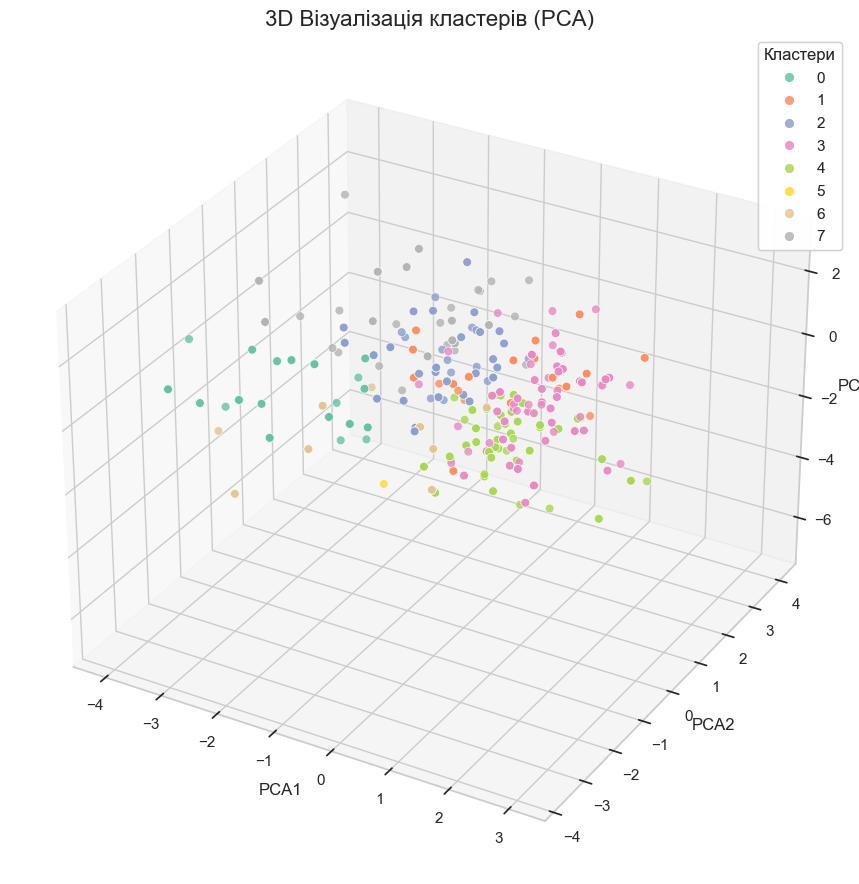

In [47]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3, random_state=42)
pca_result = pca.fit_transform(X_scaled)

df_filtered['PCA1'] = pca_result[:, 0]
df_filtered['PCA2'] = pca_result[:, 1]
df_filtered['PCA3'] = pca_result[:, 2]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_filtered['PCA1'],
    df_filtered['PCA2'],
    df_filtered['PCA3'],
    c=df_filtered['cluster'],
    cmap='Set2', s=40, alpha=0.8, edgecolor='w', linewidth=0.5
)


ax.set_title('3D Візуалізація кластерів (PCA)', fontsize=16)
ax.set_xlabel('PCA1', fontsize=12)
ax.set_ylabel('PCA2', fontsize=12)
ax.set_zlabel('PCA3', fontsize=12)


legend = ax.legend(*scatter.legend_elements(), title="Кластери", loc="upper right")
ax.add_artist(legend)


plt.tight_layout()
plt.show()

5. Аналіз кластерів

a. Для кожного кластера обчислити статистики основних ознак.
    
b. Побудувати таблицю середніх значень основних ознак або графік (heatmap).

c. Інтерпретувати кластери, наприклад:

кластер 0 — енергійні танцювальні треки з високим темпом;

кластер 1 — спокійні акустичні композиції;

кластер 2 — експериментальні інструментальні треки тощо.

Середні значення ознак по кластерах:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.866786,0.464048,-8.638619,0.296731,0.100318,2.378738e-05,0.147536,0.431976,124.304024,164671.238095
1,0.568872,0.720000,-4.787897,0.196036,0.249779,8.776923e-07,0.150046,0.437795,95.056308,186714.051282
2,0.795468,0.560831,-6.512312,0.087748,0.258543,3.403157e-03,0.134034,0.470078,104.279351,199112.025974
3,0.753752,0.758390,-4.338371,0.106837,0.163167,1.498146e-03,0.148020,0.680790,124.174943,216342.638095
4,0.649326,0.693141,-5.438065,0.083421,0.079895,2.036017e-03,0.193874,0.366834,145.652880,205703.858696
5,0.596000,0.552000,-10.278000,0.097000,0.076500,3.340000e-01,0.104000,0.112000,97.949000,229320.000000
6,0.792684,0.578842,-7.506474,0.177147,0.156147,4.083583e-03,0.535211,0.372579,113.266105,212346.157895
7,0.632333,0.431024,-8.349286,0.107088,0.623143,3.807065e-03,0.120793,0.360574,110.867548,202394.595238


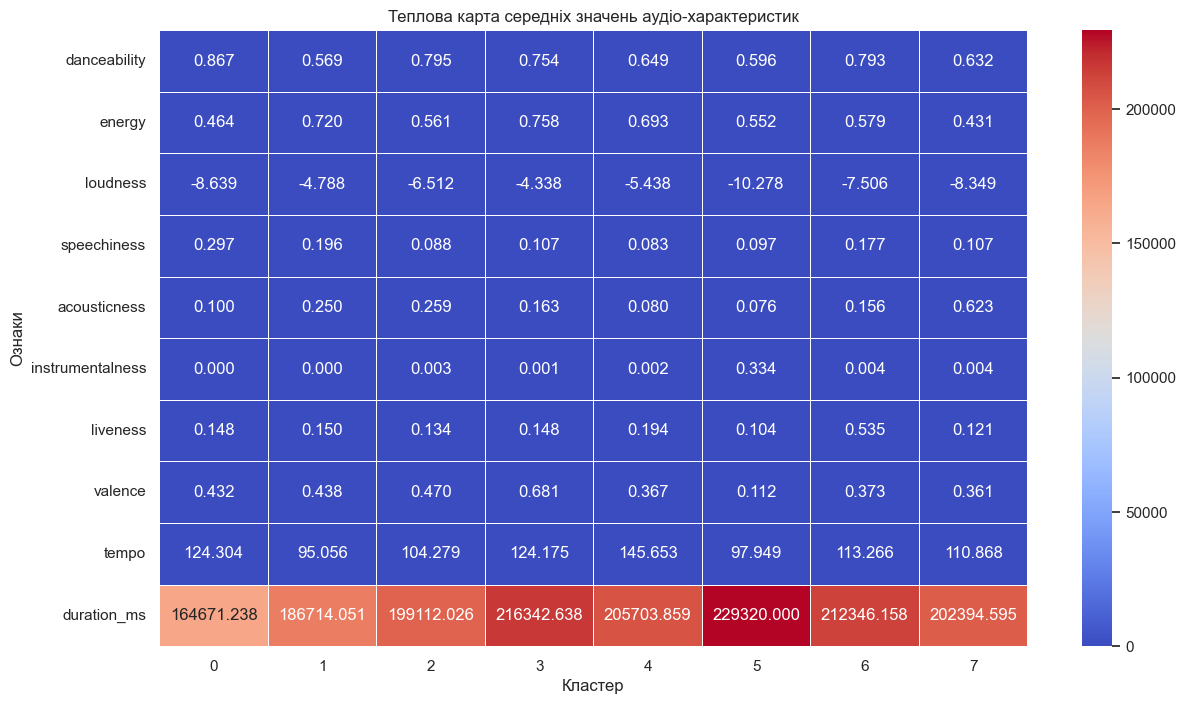

In [48]:
import seaborn as sns

cluster_means = df_filtered.groupby('cluster')[numeric_cols].mean()

print("Середні значення ознак по кластерах:")
display(cluster_means)

plt.figure(figsize=(14, 8))

sns.heatmap(cluster_means.T, annot=True, cmap='coolwarm', fmt='.3f', linewidths=.5)
plt.title('Теплова карта середніх значень аудіо-характеристик')
plt.xlabel('Кластер')
plt.ylabel('Ознаки')
plt.show()